<a href="https://colab.research.google.com/github/diazcas2/mIArmario/blob/main/MODULO4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [77]:
!pip install "rembg[cpu]" onnxruntime -q
!apt-get install -y fonts-dejavu -q

Reading package lists...
Building dependency tree...
Reading state information...
fonts-dejavu is already the newest version (2.37-2build1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [78]:
#####LIBRERÍAS
from google.colab import drive, userdata
import os
import json
import io
import requests
import google.generativeai as genai
from PIL import Image, ImageDraw, ImageOps, ImageFont
from IPython.display import display, Image as IPImage

In [79]:
drive.mount('/content/drive')
print("✅ Google Drive montado")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado


In [80]:
base = "/content/drive/MyDrive"
print("📁 Carpetas en tu Drive que contienen 'ARMARIO':")
for carpeta in os.listdir(base):
    if "ARMARIO" in carpeta.upper():
        print(f"\n✅ '{carpeta}'")
        ruta = os.path.join(base, carpeta)
        for archivo in sorted(os.listdir(ruta)):
            print(f"   - {archivo}")

📁 Carpetas en tu Drive que contienen 'ARMARIO':

✅ 'ARMARIO'
   - abrigo.jpg
   - armario.json
   - bambas.jpg
   - bomber.jpg
   - camisa.jpg
   - camisetablanca.jpg
   - jersey.jpg
   - mocasines.jpg
   - nikerojas.jpg
   - pantalontraje.png
   - polo.webp
   - running.jpg
   - sandalias.jpg
   - sudadera.jpg
   - sudaderanegra.jpg
   - vaqueroscuro.jpg
   - vaquuero.jpg
   - vermudas.jpg
   - zapatillas.jpg


In [81]:
RUTA_JSON = "/content/drive/MyDrive/ARMARIO/armario.json"
RUTA_BASE = "/content/drive/MyDrive/ARMARIO"

with open(RUTA_JSON, "r") as f:
    armario = json.load(f)

for prenda in armario:
    nombre_archivo = prenda["imagen_path"].split("/")[-1]
    prenda["imagen_path"] = f"{RUTA_BASE}/{nombre_archivo}"

print("✅ Rutas corregidas:")
for p in armario:
    existe = "✅" if __import__('os').path.exists(p["imagen_path"]) else "❌"
    print(f"  {existe} {p['tipo']} — {p['imagen_path'].split('/')[-1]}")

✅ Rutas corregidas:
  ✅ chaqueta — abrigo.jpg
  ✅ pantalón — pantalontraje.png
  ✅ camisa — polo.webp
  ✅ camisa — camisa.jpg
  ✅ chaqueta — sudaderanegra.jpg
  ✅ camiseta — jersey.jpg
  ✅ zapatos — bambas.jpg
  ✅ zapatos — mocasines.jpg
  ✅ sudadera — sudadera.jpg
  ✅ camiseta — running.jpg
  ✅ chaqueta — bomber.jpg
  ✅ zapatos — nikerojas.jpg
  ✅ zapatos — zapatillas.jpg
  ✅ pantalón — vaqueroscuro.jpg
  ✅ pantalón — vaquuero.jpg
  ✅ camiseta — camisetablanca.jpg
  ✅ zapatos — sandalias.jpg
  ✅ shorts — vermudas.jpg


In [82]:
def cargar_imagen(path):
    """Carga imagen desde archivo local o URL."""
    if path.startswith("http"):
        r = requests.get(path)
        return Image.open(io.BytesIO(r.content)).convert("RGB")
    return Image.open(path).convert("RGB")

print("✅ Imports listos")

✅ Imports listos


In [83]:
def describir_outfit(lista_prendas, estilo_ocasion):
    nombres_prendas = []

    for prenda in lista_prendas:
        nombres_prendas.append(f"{prenda.get('tipo','')} {prenda.get('color','')} ({prenda.get('formalidad','')})")

    lista_texto = "\n".join([f"- {n}" for n in nombres_prendas])

    prompt = f"""Eres un experto estilista. En máximo 15 palabras en español, describe el estilo y sensación de este outfit para: {estilo_ocasion}
Prendas: {lista_texto}
Ejemplo: "Elegante y sofisticado, perfecto para destacar en una noche especial."
Sin asteriscos, sin explicaciones, solo la frase."""

    model = genai.GenerativeModel("gemini-2.5-flash")
    response = model.generate_content(prompt)

    descripcion = response.text.strip()
    print(f"\n📝 Descripción:\n{descripcion}")
    return descripcion

In [84]:
from google.colab import drive, userdata
import os
import json
import io
import requests
import google.generativeai as genai
from PIL import Image, ImageDraw, ImageOps, ImageFont
from IPython.display import display, Image as IPImage

try:
    fuente = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 14)
    fuente_titulo = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 16)
except:
    fuente = ImageFont.load_default()
    fuente_titulo = fuente

from rembg import remove

def quitar_fondo_blanco(img):
    img_sin_fondo = remove(img)
    fondo_blanco = Image.new("RGB", img_sin_fondo.size, (255, 255, 255))
    fondo_blanco.paste(img_sin_fondo, mask=img_sin_fondo.split()[3])
    return fondo_blanco

def generar_outfit_vertical(lista_prendas, ocasion, descripcion=""):
    ANCHO        = 600
    ALTO_PRENDA  = 400
    PADDING      = 30
    COLOR_FONDO  = (255, 255, 255)
    COLOR_LINEA  = (235, 235, 235)
    COLOR_GRIS   = (150, 150, 150)
    COLOR_ACENTO = (30, 30, 30)

    n_prendas  = len(lista_prendas)
    alto_total = (ALTO_PRENDA + PADDING) * n_prendas + 250

    canvas = Image.new("RGB", (ANCHO, alto_total), COLOR_FONDO)
    draw   = ImageDraw.Draw(canvas)

    draw.text((ANCHO // 2, 38), "OUTFIT COMPLETO",
              fill=COLOR_ACENTO, anchor="mm", font=fuente_titulo)
    draw.text((ANCHO // 2, 62), f"PARA: {ocasion.upper()}",
              fill=COLOR_GRIS, anchor="mm", font=fuente)
    draw.line([(PADDING * 2, 80), (ANCHO - PADDING * 2, 80)],
              fill=COLOR_LINEA, width=1)

    y_actual = 100

    for i, prenda in enumerate(lista_prendas):
        y_celda = y_actual

        if i > 0:
            draw.line([(PADDING * 3, y_celda - PADDING // 2),
                       (ANCHO - PADDING * 3, y_celda - PADDING // 2)],
                      fill=COLOR_LINEA, width=1)

        try:
            if prenda["imagen_path"].startswith("http"):
                r = requests.get(prenda["imagen_path"])
                img_prenda = Image.open(io.BytesIO(r.content)).convert("RGB")
            else:
                img_prenda = Image.open(prenda["imagen_path"]).convert("RGB")

            img_prenda = quitar_fondo_blanco(img_prenda)

            max_w = ANCHO - PADDING * 2
            max_h = ALTO_PRENDA - 50
            ratio = min(max_w / img_prenda.width, max_h / img_prenda.height)
            pw    = int(img_prenda.width  * ratio)
            ph    = int(img_prenda.height * ratio)
            img_prenda = img_prenda.resize((pw, ph), Image.LANCZOS)

            px = (ANCHO - pw) // 2
            py = y_celda + (max_h - ph) // 2
            canvas.paste(img_prenda, (px, py))

        except Exception as e:
            draw.text((ANCHO // 2, y_celda + ALTO_PRENDA // 2),
                      f"[{prenda.get('tipo', 'prenda')}]",
                      fill=COLOR_GRIS, anchor="mm", font=fuente)
            print(f"⚠️ Error con {prenda.get('imagen_path')}: {e}")

        etiqueta = f"{prenda.get('tipo','').upper()}  ·  {prenda.get('color','').upper()}"
        draw.text((ANCHO // 2, y_celda + ALTO_PRENDA - 15),
                  etiqueta, fill=COLOR_GRIS, anchor="mm", font=fuente)

        y_actual += ALTO_PRENDA + PADDING

    if descripcion:
        draw.line([(PADDING * 2, y_actual),
                   (ANCHO - PADDING * 2, y_actual)],
                  fill=COLOR_LINEA, width=1)
        palabras     = descripcion.split()
        lineas       = []
        linea_actual = ""
        for palabra in palabras:
            if len(linea_actual) + len(palabra) + 1 <= 70:
                linea_actual += (" " if linea_actual else "") + palabra
            else:
                lineas.append(linea_actual)
                linea_actual = palabra
        if linea_actual:
            lineas.append(linea_actual)

        y_texto = y_actual + 20
        for linea in lineas[:6]:
            draw.text((ANCHO // 2, y_texto), linea,
                      fill=COLOR_GRIS, anchor="mm", font=fuente)
            y_texto += 22

    ruta_salida = "/content/outfit_temp.jpg"
    canvas.save(ruta_salida, quality=95)
    return ruta_salida


def generar_lookbook(lista_outfits, ocasion):
    imagenes = []
    for i, outfit in enumerate(lista_outfits):
        descripcion = describir_outfit(outfit, ocasion)
        ruta = generar_outfit_vertical(outfit, ocasion, descripcion)
        ruta_nueva = f"/content/outfit_{i+1}.jpg"
        os.rename(ruta, ruta_nueva)
        imagenes.append(Image.open(ruta_nueva))

    ancho_total = sum(img.width for img in imagenes)
    alto_total = max(img.height for img in imagenes)

    lookbook = Image.new("RGB", (ancho_total, alto_total), (255, 255, 255))
    x = 0
    for img in imagenes:
        lookbook.paste(img, (x, 0))
        x += img.width

    ruta_lookbook = "/content/lookbook_final.jpg"
    lookbook.save(ruta_lookbook, quality=95)
    display(IPImage(filename=ruta_lookbook))
    return ruta_lookbook

In [85]:
genai.configure(api_key=userdata.get('GEMINI_API_KEY'))

def describir_outfit(lista_prendas, estilo_ocasion):
    nombres = [f"{p.get('tipo')} {p.get('color','')}" for p in lista_prendas]
    lista_texto = ", ".join(nombres)
    prompt = f"""En máximo 2 frases en español, describe si este outfit
es apropiado para: {estilo_ocasion}
Prendas: {lista_texto}"""
    model    = genai.GenerativeModel("gemini-2.5-flash")
    response = model.generate_content(prompt)
    return response.text.strip()

def modulo_4(prendas_seleccionadas, ocasion_detectada):
    """
    Entrada: lista de prendas del armario.json + ocasión del Módulo 1
    Salida:  imagen del outfit en layout vertical
    """

    descripcion = describir_outfit(prendas_seleccionadas, ocasion_detectada)

    ruta = generar_outfit_vertical(prendas_seleccionadas, ocasion_detectada, descripcion)
    display(IPImage(filename=ruta))
    return ruta

print("✅ Módulo 4 listo")

✅ Módulo 4 listo


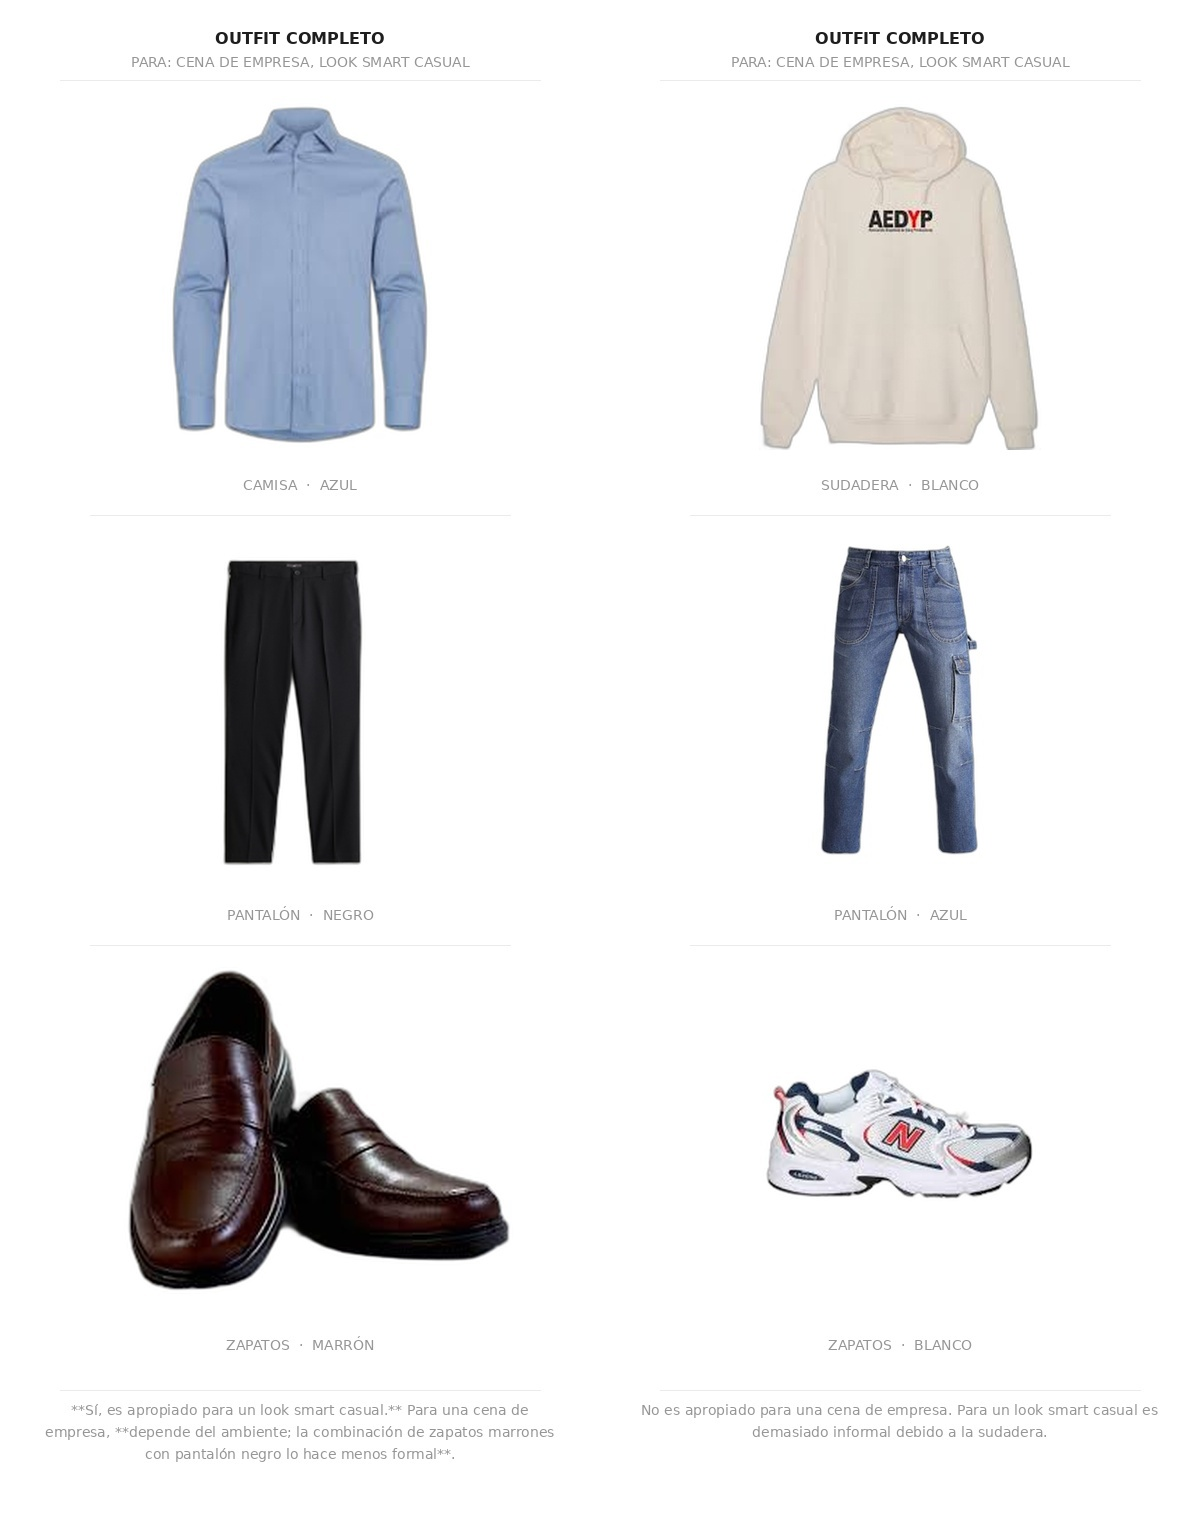

'/content/lookbook_final.jpg'

In [86]:
# Outfit 1 - Smart casual para cena de empresa
outfit1 = [
    next(p for p in armario if p["id"] == "prenda_004_1"),  # camisa azul formal
    next(p for p in armario if p["id"] == "prenda_002_1"),  # pantalón negro
    next(p for p in armario if p["id"] == "prenda_008_1"),  # mocasines marrón
]

# Outfit 2 - Casual para fin de semana
outfit2 = [
    next(p for p in armario if p["id"] == "prenda_009_1"),  # sudadera blanca
    next(p for p in armario if p["id"] == "prenda_015_1"),  # vaquero azul
    next(p for p in armario if p["id"] == "prenda_007_1"),  # bambas blancas
]

mi_ocasion = "cena de empresa, look smart casual"

generar_lookbook([outfit1, outfit2], mi_ocasion)